In [144]:
import os

from IPython.core.completerlib import import_re
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F
import torch.nn as nn

In [145]:
class CNN (nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, stride=1)
        self.conv2 = nn.LazyConv2d(out_channels=16, kernel_size=3, stride=1)

        self.fc1 = nn.LazyLinear(out_features=128)
        self.fc2 = nn.LazyLinear(out_features=96)
        self.fc3 = nn.LazyLinear(out_features=10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, kernel_size=2, stride=2)
        x = x.flatten(start_dim=1)

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        x = F.log_softmax(x, dim=1)

        return x

Label: 8, Predicted: 8, True
Label: 9, Predicted: 9, True
Label: 4, Predicted: 4, True
Label: 5, Predicted: 5, True
Label: 7, Predicted: 7, True
Label: 6, Predicted: 6, True
Label: 2, Predicted: 2, True
Label: 3, Predicted: 3, True
Label: 1, Predicted: 8, False
Label: 0, Predicted: 0, True


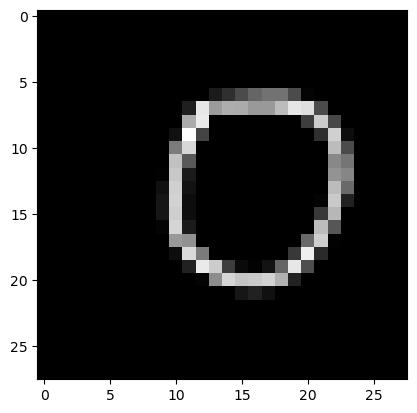

In [162]:
model = CNN()
model.load_state_dict(torch.load(r"./Model/MNIST.pt", weights_only=True))

image_folder = r"/Users/xuweining/Desktop/Selfmake_MNIST"
images = []

for img in os.scandir(image_folder):
    img_name = int(img.name.replace(".jpg", ""))
    img = Image.open(img.path).resize((28, 28)).convert("L")
    plt.imshow(img, cmap="Greys")

    img_tensor = torch.Tensor((255-np.array(img))).reshape(1, 1, 28, 28)
    img.close()

    with torch.no_grad():
        predicted_number = model(img_tensor).argmax()
        print(f"Label: {img_name}, Predicted: {predicted_number.item()}, {img_name == predicted_number.item()}")